# Car Sales Analysis: Customer, Vehicle, and Temporal Patterns

This notebook explores a car sales dataset to understand how vehicle characteristics, customer demographics, and time-related trends differ across high and low priced car purchases.

Goal:  identify meaningful patterns that can inform retail strategy and market insights.


# To answer:
1. Which customer demographics are associated with low, mid, and high-priced cars?
2. Which vehicle characteristics (brand, model, body style, transmission, etc.) are most strongly associated with high-priced purchases?
3. How do car sales and prices vary over time (months/years)?


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv("/Users/courtney/Desktop/car-sales/data/raw/Car Sales.xlsx - car_data.csv")

#df.head()
#df.info()
df.columns
# df.describe()

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [62]:
# Parse Dates

df['date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')  # adjust format if needed
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df.head()


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,date,year,month
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown,2022-01-02,2022,1
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora,2022-01-02,2022,1
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville,2022-01-02,2022,1
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco,2022-01-02,2022,1
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville,2022-01-02,2022,1


## Price Distribution

In [63]:
df['Price ($)'].describe()

count    23906.000000
mean     28090.247846
std      14788.687608
min       1200.000000
25%      18001.000000
50%      23000.000000
75%      34000.000000
max      85800.000000
Name: Price ($), dtype: float64

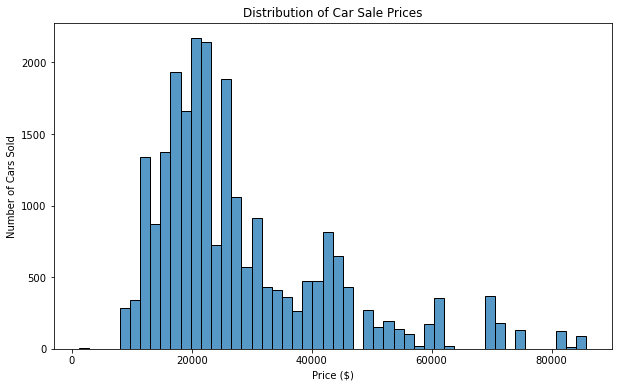

In [64]:
plt.figure(figsize=(10,6))
sns.histplot(df['Price ($)'], bins=50)
plt.title("Distribution of Car Sale Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Cars Sold")
plt.show()


The distribution of car sale prices is right-skewed, with most vehicles selling in the $15,000–$35,000 range and a smaller number of high-priced vehicles extending the upper tail. The mean price ($28,090) exceeds the median ($23,000), showing that premium vehicle sales pull the average upward. This wide spread in prices motivates segmenting cars into low, mid, and high price categories to better understand how customer demographics, vehicle characteristics, and timing differ across price levels.


In [65]:
df['price_bucket'] = pd.qcut(
    df['Price ($)'],
    q=3,
    labels=['Low', 'Mid', 'High']
)


In [66]:
df

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region,date,year,month,price_bucket
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown,2022-01-02,2022,1,Mid
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora,2022-01-02,2022,1,Low
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville,2022-01-02,2022,1,High
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco,2022-01-02,2022,1,Low
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville,2022-01-02,2022,1,Mid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco,2023-12-31,2023,12,Low
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown,2023-12-31,2023,12,Low
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale,2023-12-31,2023,12,Mid
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin,2023-12-31,2023,12,High


## Customer Demographics and Price Segmentation

In [67]:
df['Annual Income'].describe()


count    2.390600e+04
mean     8.308403e+05
std      7.200064e+05
min      1.008000e+04
25%      3.860000e+05
50%      7.350000e+05
75%      1.175750e+06
max      1.120000e+07
Name: Annual Income, dtype: float64

In [68]:
df.groupby('price_bucket')['Annual Income'].describe()


,count,mean,std,min,25%,50%,75%,max
price_bucket,,,,,,,,
Low,8348.0,809753.211428,704809.235142,13500.0,350000.0,720500.0,1150000.0,6800000.0
Mid,7816.0,837561.420292,724144.247109,10080.0,400000.0,743000.0,1190000.0,11200000.0
High,7742.0,846792.558254,731490.907205,13500.0,401625.0,743000.0,1190000.0,8000000.0


Car price tier is not strongly differentiated by customer income alone, suggesting other factors (vehicle characteristics, timing, or preferences) may play a larger role in high-priced purchases.

In [69]:
# Cap annual income at the 99th percentile
cap_value = df['Annual Income'].quantile(0.99)
df['Annual_Income_capped'] = df['Annual Income'].clip(upper=cap_value)


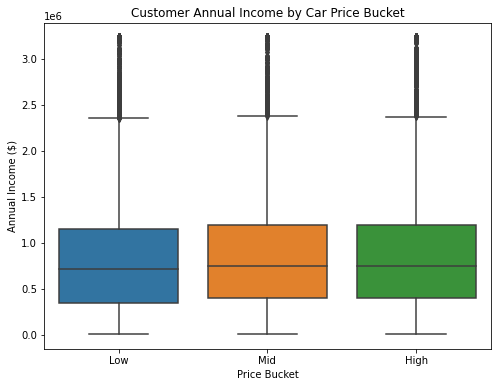

In [70]:
plt.figure(figsize=(8,6))
sns.boxplot(x='price_bucket', y='Annual_Income_capped', data=df)
plt.title('Customer Annual Income by Car Price Bucket')
plt.xlabel('Price Bucket')
plt.ylabel('Annual Income ($)')
plt.show()


# Vehicle Characteristics by Price Bucket

How do vehicle features differ across low, mid, and high priced cars?

In [87]:
# Company vs Price Bucket

pd.set_option('display.max_columns', None)

company_counts = df.groupby('price_bucket')['Company'].value_counts(normalize=True).unstack() *100
company_counts


Company,Acura,Audi,BMW,Buick,Cadillac,Chevrolet,Chrysler,Dodge,Ford,Honda,Hyundai,Infiniti,Jaguar,Jeep,Lexus,Lincoln,Mercedes-B,Mercury,Mitsubishi,Nissan,Oldsmobile,Plymouth,Pontiac,Porsche,Saab,Saturn,Subaru,Toyota,Volkswagen,Volvo
price_bucket,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Low,3.030666,2.719214,4.240537,2.132247,0.407283,7.738380,4.911356,5.893627,7.343076,1.940585,1.545280,0.443220,0.814566,2.731193,2.491615,2.815046,6.336847,3.797317,6.013416,4.180642,4.480115,2.539530,4.635841,1.185913,0.299473,2.587446,1.257786,3.114518,5.773838,2.599425
Mid,3.352098,2.315763,3.416070,0.716479,2.558854,8.828045,5.846981,8.431423,5.066530,4.004606,1.727226,1.125896,0.985159,0.985159,2.827533,0.908393,4.426817,3.313715,4.861822,3.582395,2.328557,3.326510,1.087513,2.699591,1.445752,1.138690,2.801945,5.463153,6.384340,4.042989
High,2.247481,0.774994,2.182898,2.647895,5.399122,6.238698,3.267889,6.716611,7.814518,3.009558,NaN,0.904159,0.452080,0.749160,4.817877,2.402480,5.295789,3.849135,5.102041,3.319556,7.168690,1.872901,4.184965,0.658745,0.929992,3.629553,1.046241,5.463704,4.546629,3.306639


The distribution of car companies across low, mid, and high price tiers shows that luxury brands (e.g. Cadillac, Mercedes-Benz, Porsche) are more prevalent in the high price category. Mass-market brands (e.g. Ford, Chevrolet, Toyota) make up the lower and middle tiers. Oldsmobile shows a high price outlier, possibly driven by a few expensive cars.

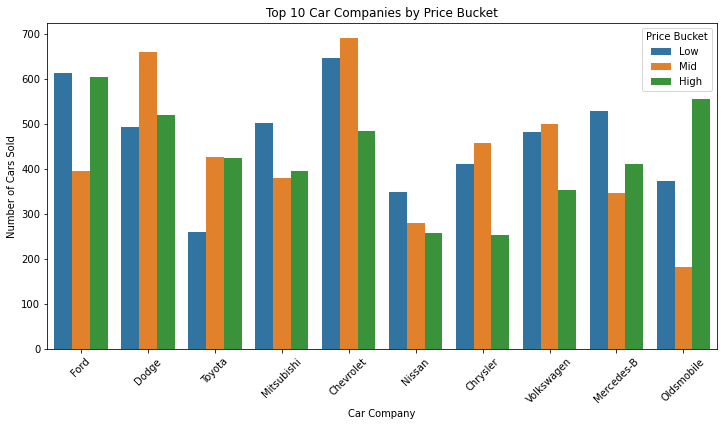

In [73]:
# Top 10 most common companies in each price bucket
top_companies = df['Company'].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.countplot(
    x='Company',
    hue='price_bucket',
    data=df[df['Company'].isin(top_companies)]
)
plt.title("Top 10 Car Companies by Price Bucket")
plt.xlabel("Car Company")
plt.ylabel("Number of Cars Sold")
plt.xticks(rotation=45)
plt.legend(title='Price Bucket')
plt.show()

While mass-market brands like Ford, Dodge, Toyota, and Mitsubishi have strong representation across low, mid, and high price tiers, some luxury/outlier models (e.g. Oldsmobile) appear more frequently in the high price bucket. 

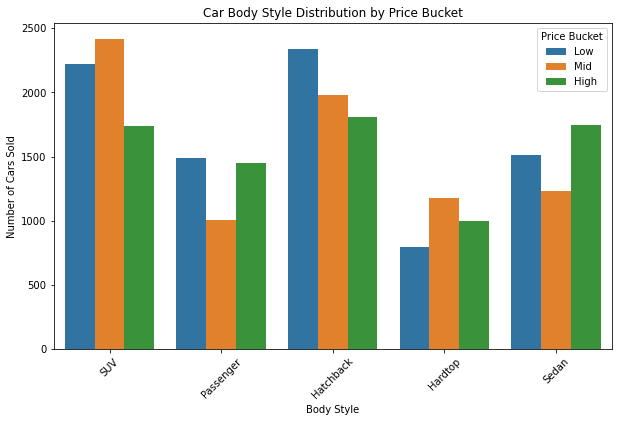

In [74]:
# Body Style vs Price Bucket
plt.figure(figsize=(10,6))
sns.countplot(
    x='Body Style',
    hue='price_bucket',
    data=df
)
plt.title("Car Body Style Distribution by Price Bucket")
plt.xlabel("Body Style")
plt.ylabel("Number of Cars Sold")
plt.xticks(rotation=45)
plt.legend(title='Price Bucket')
plt.show()

SUVs and hatchbacks make up the majority of low and mid priced tiers. Sedans and hardtops are slighly more frequent among higher-priced purchased. This suggests that while larger utiity vehicles are common, some high-end sedans and hardtops come with premium pricing.

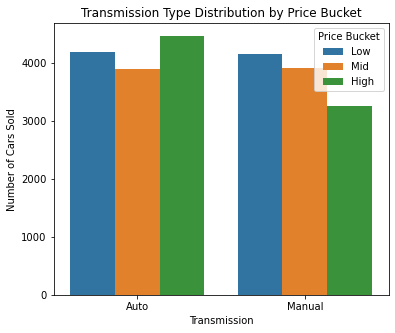

In [75]:
# Transmission vs Price Bucket
plt.figure(figsize=(6,5))
sns.countplot(
    x='Transmission',
    hue='price_bucket',
    data=df
)
plt.title("Transmission Type Distribution by Price Bucket")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars Sold")
plt.legend(title='Price Bucket')
plt.show()


Automatic transmissions dominated high priced cars. Low and mid priced cars have roughly equal representation of manual and automatic transmissions.

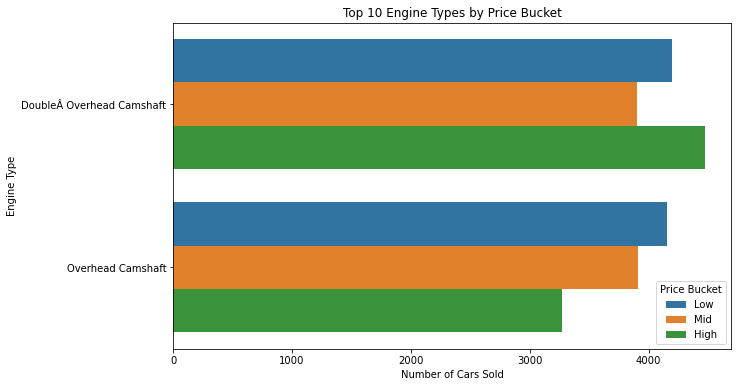

In [76]:
# Engine Type vs Price Bucket
plt.figure(figsize=(10,6))
sns.countplot(
    y='Engine',
    hue='price_bucket',
    data=df,
    order=df['Engine'].value_counts().head(10).index  # top 10 engine types
)
plt.title("Top 10 Engine Types by Price Bucket")
plt.xlabel("Number of Cars Sold")
plt.ylabel("Engine Type")
plt.legend(title='Price Bucket')
plt.show()


High priced cars are more likely to have double overhead camshaft engines (more efficient), which reflects higher-performance/luxury cars. Low priced cars more often have single overhead camshaft engines (simpler, cheaper design than double overhead camshaft engines).